# Notebook 5: Solving the Same Problem with FEniCS

In the previous notebook, we used **scikit-fem**.  
Now we solve the same type of problem using **classic FEniCS** (the `fenics` package).

We again solve

$$
\nabla^2 u = 1 \quad 	\text{in } \Omega = [0,1]^2,
\qquad
u=0 \quad 	\text{on } \partial \Omega.
$$

## Learning goals

By the end of this notebook, you should be able to:

- create a simple 2D mesh in FEniCS,
- define a function space,
- write the weak form,
- impose Dirichlet boundary conditions,
- solve the PDE,
- and visualize the numerical solution.


## Installation note

This notebook uses **legacy FEniCS**, usually imported as:

```python
from fenics import *
```

The FEniCS Project notes that **legacy FEniCS 2019.1.0** is the last release of the classic package, while **FEniCSx** is the newer generation. The legacy documentation and demos are still available and are often easier to match with older tutorials. citeturn418713search0turn418713search1turn418713search3

Typical installation routes for classic FEniCS include:

- Ubuntu package installation,
- a Conda environment with `fenics`,
- or Docker. citeturn418713search2turn418713search0

If the import below fails, the package is probably not installed in your current Python environment.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import *


## Step 1: Create a unit square mesh

We create a triangular mesh on the domain $[0,1]	\times[0,1]$.


In [21]:
mesh = UnitSquareMesh(20, 20)
print(mesh)
print("Number of vertices:", mesh.num_vertices())
print("Number of cells:", mesh.num_cells())


Number of vertices: 441
Number of cells: 800


## Step 2: Define a function space

We use continuous piecewise linear functions, often called $P_1$ or Lagrange degree 1 elements.


In [22]:
V = FunctionSpace(mesh, "P", 1)
print(V)


FunctionSpace(Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 66), FiniteElement('Lagrange', triangle, 1))


## Step 3: Define the boundary condition

We want

$$
u = 0 \quad 	\text{on } \partial \Omega.
$$

In FEniCS, we define a function that identifies the boundary and then apply a Dirichlet condition.


In [23]:
u_D = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)
print("Boundary condition created.")


Boundary condition created.


## Step 4: Define the weak form

The weak form is:

Find $u \in V$ such that

$$
\int_\Omega 
\nabla u \cdot 
\nabla v\,dx = \int_\Omega f v\,dx
$$

for all test functions $v \in V$.

Here we choose

$$
f = 1.
$$


In [24]:
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.0)

a = dot(grad(u), grad(v)) * dx
L = f * v * dx


## Step 5: Solve the linear system

FEniCS assembles the matrix and right-hand side for us.


In [25]:
uh = Function(V)
solve(a == L, uh, bc)

print("Solution computed.")


Solving linear variational problem.
Solution computed.


In [26]:
vertex_values = uh.compute_vertex_values(mesh)
print("Minimum value:", vertex_values.min())
print("Maximum value:", vertex_values.max())


Minimum value: 0.0
Maximum value: 0.07352670923339054


## Step 6: Visualize the solution

We first plot the mesh and then the FEM solution.


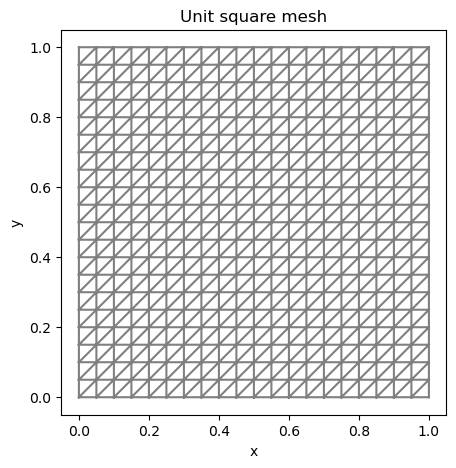

In [27]:
plt.figure(figsize=(5, 5))
plot(mesh)
plt.title("Unit square mesh")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


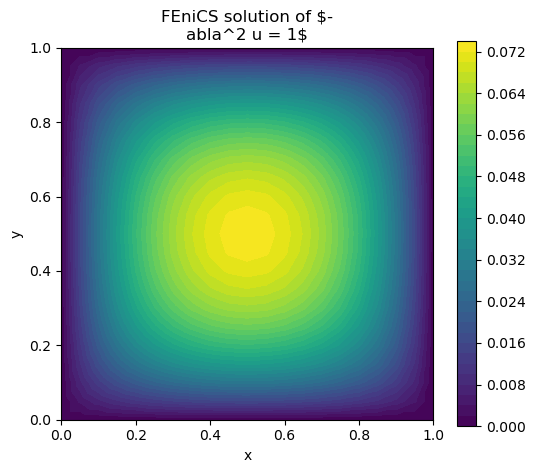

In [28]:
plt.figure(figsize=(6, 5))
p = plot(uh)
plt.colorbar(p)
plt.title("FEniCS solution of $-\nabla^2 u = 1$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


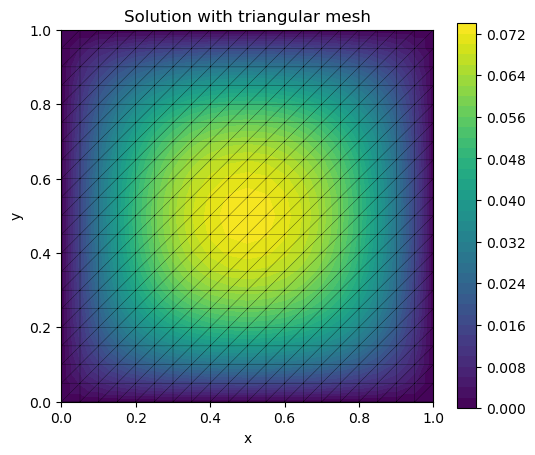

In [29]:
plt.figure(figsize=(6, 5))
p = plot(uh)
plt.colorbar(p)
plt.triplot(mesh.coordinates()[:, 0], mesh.coordinates()[:, 1], mesh.cells(), color='k', linewidth=0.2)
plt.title("Solution with triangular mesh")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Step 7: Changing the mesh resolution

A finer mesh usually gives a more accurate solution, but also increases the cost.


In [30]:
def solve_fenics_poisson(n):
    mesh_n = UnitSquareMesh(n, n)
    V_n = FunctionSpace(mesh_n, "P", 1)

    u = TrialFunction(V_n)
    v = TestFunction(V_n)
    f = Constant(1.0)

    a = dot(grad(u), grad(v)) * dx
    L = f * v * dx

    bc = DirichletBC(V_n, Constant(0.0), boundary)

    uh_n = Function(V_n)
    solve(a == L, uh_n, bc)
    return mesh_n, V_n, uh_n

mesh2, V2, uh2 = solve_fenics_poisson(10)
mesh3, V3, uh3 = solve_fenics_poisson(40)


Solving linear variational problem.
Solving linear variational problem.


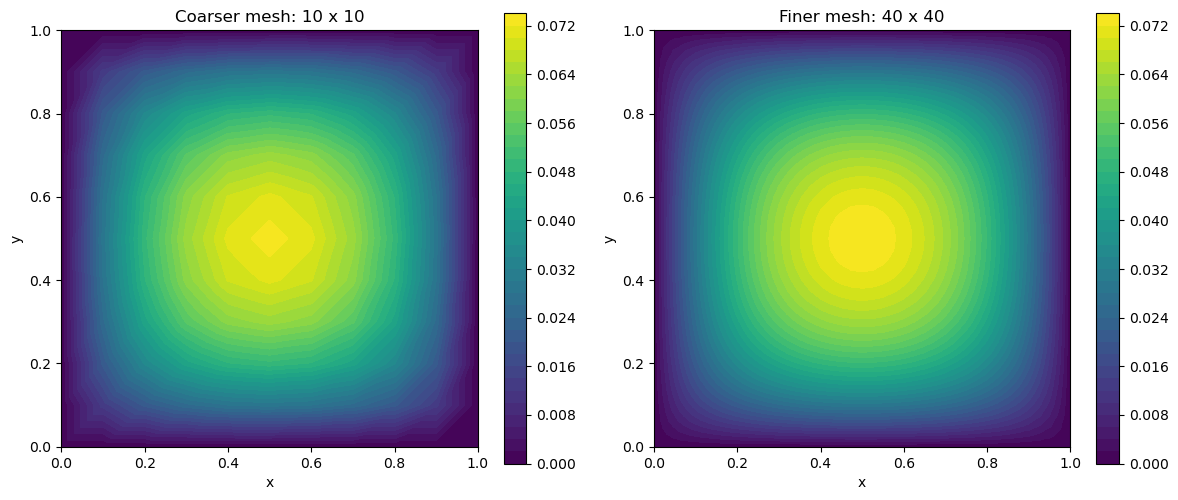

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
p1 = plot(uh2)
plt.colorbar(p1)
plt.title("Coarser mesh: 10 x 10")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1, 2, 2)
p2 = plot(uh3)
plt.colorbar(p2)
plt.title("Finer mesh: 40 x 40")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()


## Discussion

Things to notice:

- The maximum value occurs near the center of the square.
- The solution is zero on the boundary because of the Dirichlet condition.
- The code is shorter than the hand-built solver because FEniCS automatically handles assembly and solving.

## Exercises

1. Change the right-hand side from $f=1$ to $f=10$.
2. Try a different mesh size.
3. Replace the unit square by a rectangular mesh.
4. Compare this notebook with the scikit-fem notebook: what ideas are the same?

## Final note

The FEniCS Project currently recommends **FEniCSx** for new users, and states that classic FEniCS is the legacy line, with **2019.1.0** as the latest legacy release. Legacy docs remain available through the old documentation site. citeturn418713search0turn418713search3turn418713search6

That makes classic FEniCS useful for teaching and for matching older tutorials, while FEniCSx is the modern path for newer workflows. citeturn418713search0turn418713search3
